# Download and plot Comet metrics

Edit the configuration cell, then run the notebook. It downloads the requested metrics from the selected Comet projects and plots all downloaded series on the same axis.

In [1]:
# Comet credentials
COMET_API_KEY = "o77J6VCMDamustkfJuMXZ2jdV"
COMET_WORKSPACE = "maurice-filo"

# Comet projects to download from.
PROJECT_NAMES = [
    "logic-circuit-ablation-full",
    "logic-circuit-ablation-half-risk",
    "logic-circuit-ablation-no-risk",
    "logic-circuit-ablation-no-sil",
    "logic-circuit-ablation-no-entropy",
]

# Metrics to download and plot. The notebook makes one figure per label.
# Use "name" for exact Comet metric names, or "template" for metrics with project-specific K.
METRIC_REQUESTS = [
    {"label": "Loss: Batch Best", "name": "Loss: Batch Best"},
    {"label": "Loss: Top-K Average", "template": "Loss: Top-{k} Average"},
]
METRIC_NAMES = [request["label"] for request in METRIC_REQUESTS]

# Top-K metric resolution: Comet logs names like "Loss: Top-12 Average".
# K follows the trainer code: k = int(batch_size * (1 - risk)).
BATCH_SIZE_FOR_TOPK = 1280
PROJECT_RISK_VALUES = {
    "logic-circuit-ablation-full": 0.9,
    "logic-circuit-ablation-half-risk": 0.5,
    "logic-circuit-ablation-no-risk": 0.0,
    "logic-circuit-ablation-no-sil": 0.9,
    "logic-circuit-ablation-no-entropy": 0.9,
}

# Optional experiment filters.
EXPERIMENT_NAME_PATTERN = None  # regex, example: r"2026-05-26"
MAX_EXPERIMENTS_PER_PROJECT = None

# Sparse Comet fallbacks often contain only min/max points and plot as misleading straight lines.
MIN_POINTS_PER_SERIES = 10
SKIP_SPARSE_SERIES = True

# Output folders.
METRICS_OUTPUT_ROOT = "comet_metric_downloads"
COMBINED_CSV_NAME = "combined_metrics.csv"
FIGURES_OUTPUT_ROOT = "figures"

# Plot styling.
PLOT_TITLE = "Ablation analysis for logic circuit task"
PANEL_LABEL = ""
X_AXIS_LABEL = "epochs"
X_AXIS_SCALE = 1  # set to batch size if you want step -> full task simulations
Y_AXIS_LABEL = "best loss in current batch"
METRIC_Y_LABELS = {
    "Loss: Batch Best": "best loss in current batch",
    "Loss: Top-K Average": "average loss in top-K",
}
METRIC_TITLES = {
    "Loss: Batch Best": PLOT_TITLE,
    "Loss: Top-K Average": "Loss: Top-K Average vs step",
}
USE_LOG_Y = True
PROJECT_LABELS = {
    "logic-circuit-ablation-full": "Full",
    "logic-circuit-ablation-half-risk": "Half risk",
    "logic-circuit-ablation-no-risk": "No risk",
    "logic-circuit-ablation-no-sil": "No SIL",
    "logic-circuit-ablation-no-entropy": "No entropy",
}
PROJECT_COLORS = {
    "logic-circuit-ablation-full": "#0072B2",
    "logic-circuit-ablation-half-risk": "#E69F00",
    "logic-circuit-ablation-no-risk": "#D55E00",
    "logic-circuit-ablation-no-sil": "#009E73",
    "logic-circuit-ablation-no-entropy": "#CC79A7",
}

In [2]:
from pathlib import Path
import re
from typing import Any

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from comet_ml import API

api = API(api_key=COMET_API_KEY)
workspace = COMET_WORKSPACE
output_root = Path(METRICS_OUTPUT_ROOT)
output_root.mkdir(parents=True, exist_ok=True)
figures_output_root = Path(FIGURES_OUTPUT_ROOT)
figures_output_root.mkdir(parents=True, exist_ok=True)

In [3]:
def safe_name(value: Any, default: str = "unknown") -> str:
    text = str(value or default).strip()
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text)
    return text.strip("._") or default


def experiment_name(experiment) -> str:
    name_attr = getattr(experiment, "name", None)
    if name_attr:
        return str(name_attr)
    get_name = getattr(experiment, "get_name", None)
    return str(get_name() if callable(get_name) else experiment.key)


def matches_pattern(value: str, pattern: str | None) -> bool:
    return pattern is None or re.search(pattern, value) is not None


def first_existing_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for column in candidates:
        if column in df.columns:
            return column
    return None


def topk_for_project(project_name: str) -> int:
    risk = PROJECT_RISK_VALUES[project_name]
    return max(1, int(BATCH_SIZE_FOR_TOPK * (1.0 - risk)))


def metric_requests_for_project(project_name: str) -> list[dict[str, str]]:
    requests = []
    k = topk_for_project(project_name)
    for request in METRIC_REQUESTS:
        label = request["label"]
        if "template" in request:
            comet_name = request["template"].format(k=k, risk=PROJECT_RISK_VALUES[project_name])
        else:
            comet_name = request["name"]
        requests.append({"label": label, "comet_name": comet_name, "k": k})
    return requests


def normalize_metric_df(
    df: pd.DataFrame,
    project_name: str,
    experiment,
    metric_name: str,
    metric_label: str | None = None,
    top_k: int | None = None,
) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()

    df = df.copy()
    value_column = first_existing_column(df, ["value", "metricValue", "metric_value", "valueCurrent"])
    step_column = first_existing_column(df, ["step", "global_step", "x", "stepCurrent"])

    if value_column is None:
        raise ValueError(f"No metric value column found for {metric_name}. Columns: {list(df.columns)}")

    if step_column is None:
        df["step"] = range(len(df))
        step_column = "step"

    normalized = pd.DataFrame(
        {
            "project": project_name,
            "experiment_name": experiment_name(experiment),
            "experiment_key": str(experiment.key),
            "metric": metric_label or metric_name,
            "comet_metric": metric_name,
            "top_k": top_k,
            "step": pd.to_numeric(df[step_column], errors="coerce"),
            "value": pd.to_numeric(df[value_column], errors="coerce"),
        }
    )

    if "timestamp" in df.columns:
        normalized["timestamp"] = df["timestamp"]
    if "datetime" in df.columns:
        normalized["datetime"] = df["datetime"]
    if "download_source" in df.columns:
        normalized["download_source"] = df["download_source"]

    return normalized.dropna(subset=["step", "value"]).sort_values("step")


def download_metric_df(experiment, metric_name: str) -> pd.DataFrame:
    try:
        experiment.get_metrics_summary(metric_name)
    except TypeError:
        experiment.get_metrics_summary()

    frames = []

    metric_records = experiment.get_metrics(metric_name)
    records_df = pd.DataFrame(metric_records or [])
    if not records_df.empty:
        records_df["download_source"] = "get_metrics"
        frames.append(records_df)

    try:
        total_df = experiment.get_metric_total_df(metric_name, fallback_to_sampled_data=False)
    except TypeError:
        total_df = experiment.get_metric_total_df(metric_name)

    if total_df is not None and not total_df.empty:
        total_df = total_df.copy()
        total_df["download_source"] = "get_metric_total_df"
        frames.append(total_df)

    if frames:
        return max(frames, key=len)

    sampled_df = experiment.get_metric_total_df(metric_name)
    if sampled_df is not None and not sampled_df.empty:
        sampled_df = sampled_df.copy()
        sampled_df["download_source"] = "sampled_fallback"
        return sampled_df

    return pd.DataFrame()

In [4]:
metric_frames = []

for project_name in PROJECT_NAMES:
    print(f"\nProject: {project_name}")
    experiments = list(api.get_experiments(workspace, project_name))
    experiments = [
        experiment
        for experiment in experiments
        if matches_pattern(experiment_name(experiment), EXPERIMENT_NAME_PATTERN)
    ]

    if MAX_EXPERIMENTS_PER_PROJECT is not None:
        experiments = experiments[:MAX_EXPERIMENTS_PER_PROJECT]

    project_metric_requests = metric_requests_for_project(project_name)
    print(f"  matched experiments: {len(experiments)}")
    print(
        "  metrics: "
        + ", ".join(
            f"{request['label']} -> {request['comet_name']}" for request in project_metric_requests
        )
    )

    for experiment in experiments:
        exp_name = experiment_name(experiment)
        exp_key = str(experiment.key)
        print(f"  - {exp_name} ({exp_key})")

        experiment_dir = output_root / safe_name(project_name) / f"{safe_name(exp_name)}__{safe_name(exp_key)}"
        experiment_dir.mkdir(parents=True, exist_ok=True)

        for metric_request in project_metric_requests:
            metric_label = metric_request["label"]
            metric_name = metric_request["comet_name"]
            raw_df = download_metric_df(experiment, metric_name)
            metric_df = normalize_metric_df(
                raw_df,
                project_name,
                experiment,
                metric_name,
                metric_label=metric_label,
                top_k=metric_request.get("k"),
            )

            if metric_df.empty:
                print(f"      missing or empty metric: {metric_label} ({metric_name})")
                continue

            source = metric_df["download_source"].iloc[0] if "download_source" in metric_df else "unknown"
            if len(metric_df) < MIN_POINTS_PER_SERIES:
                print(
                    f"      sparse metric: {metric_label} ({metric_name}) has only {len(metric_df)} points "
                    f"from {source}; likely a sampled Comet fallback"
                )
                if SKIP_SPARSE_SERIES:
                    continue

            metric_path = experiment_dir / f"{safe_name(metric_label)}__{safe_name(metric_name)}.csv"
            metric_df.to_csv(metric_path, index=False)
            metric_frames.append(metric_df)
            print(f"      {metric_label} ({metric_name}): {len(metric_df)} points from {source} -> {metric_path}")

if metric_frames:
    metrics_df = pd.concat(metric_frames, ignore_index=True)
else:
    metrics_df = pd.DataFrame(columns=["project", "experiment_name", "experiment_key", "metric", "comet_metric", "top_k", "step", "value"])

combined_path = output_root / COMBINED_CSV_NAME
metrics_df.to_csv(combined_path, index=False)
print(f"\nCombined metrics written to: {combined_path.resolve()}")
metrics_df.head()


Project: logic-circuit-ablation-full
  matched experiments: 3
  metrics: Loss: Batch Best -> Loss: Batch Best, Loss: Top-K Average -> Loss: Top-127 Average
  - Logic_Circuit_Ablation_Full_2026-05-22 15:19:36 (580dfd7d22ec4ad19273ee813ff38120)
      Loss: Batch Best (Loss: Batch Best): 400 points from get_metrics -> comet_metric_downloads/logic-circuit-ablation-full/Logic_Circuit_Ablation_Full_2026-05-22_15_19_36__580dfd7d22ec4ad19273ee813ff38120/Loss_Batch_Best__Loss_Batch_Best.csv
      Loss: Top-K Average (Loss: Top-127 Average): 400 points from get_metrics -> comet_metric_downloads/logic-circuit-ablation-full/Logic_Circuit_Ablation_Full_2026-05-22_15_19_36__580dfd7d22ec4ad19273ee813ff38120/Loss_Top-K_Average__Loss_Top-127_Average.csv
  - Logic_Circuit_Ablation_Full_2026-05-31 06:45:30 (f8c6ecbbaf1f46c48c032abbcc08380b)
      Loss: Batch Best (Loss: Batch Best): 400 points from get_metrics -> comet_metric_downloads/logic-circuit-ablation-full/Logic_Circuit_Ablation_Full_2026-05-31_0

,project,experiment_name,experiment_key,metric,comet_metric,top_k,step,value,timestamp,download_source
0,logic-circuit-ablation-full,Logic_Circuit_Ablation_Full_2026-05-22 15:19:36,580dfd7d22ec4ad19273ee813ff38120,Loss: Batch Best,Loss: Batch Best,127,0,0.222396,1779456050111,get_metrics
1,logic-circuit-ablation-full,Logic_Circuit_Ablation_Full_2026-05-22 15:19:36,580dfd7d22ec4ad19273ee813ff38120,Loss: Batch Best,Loss: Batch Best,127,1,0.210651,1779456132336,get_metrics
2,logic-circuit-ablation-full,Logic_Circuit_Ablation_Full_2026-05-22 15:19:36,580dfd7d22ec4ad19273ee813ff38120,Loss: Batch Best,Loss: Batch Best,127,2,0.145754,1779456191484,get_metrics
3,logic-circuit-ablation-full,Logic_Circuit_Ablation_Full_2026-05-22 15:19:36,580dfd7d22ec4ad19273ee813ff38120,Loss: Batch Best,Loss: Batch Best,127,3,0.148886,1779456251441,get_metrics
4,logic-circuit-ablation-full,Logic_Circuit_Ablation_Full_2026-05-22 15:19:36,580dfd7d22ec4ad19273ee813ff38120,Loss: Batch Best,Loss: Batch Best,127,4,0.202955,1779456313353,get_metrics


Saved figure to figures/Loss_Batch_Best.pdf


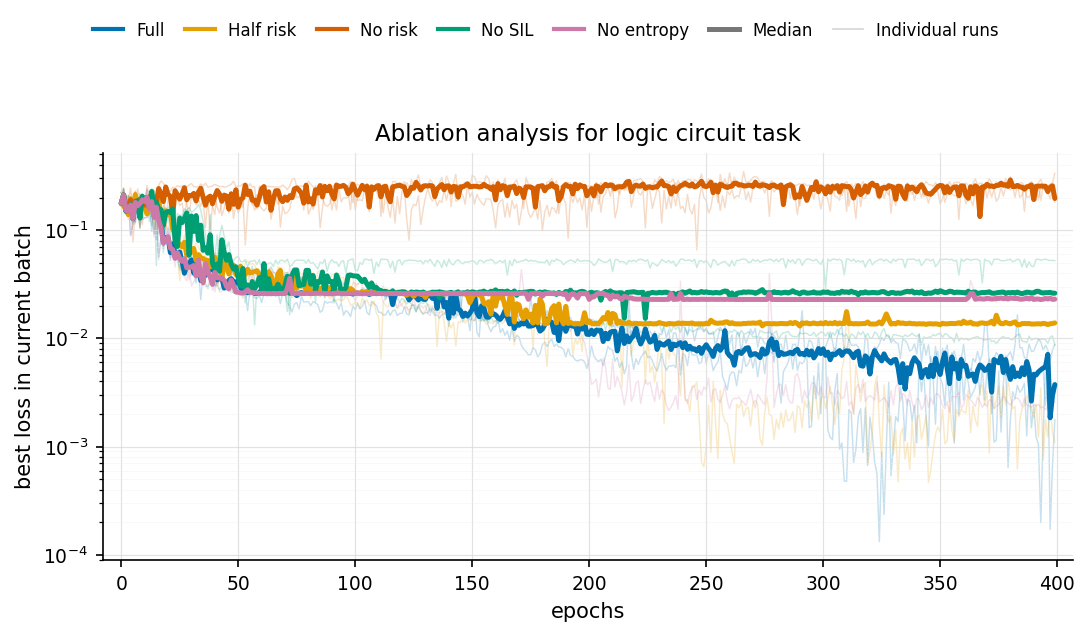

Saved figure to figures/Loss_Top-K_Average.pdf


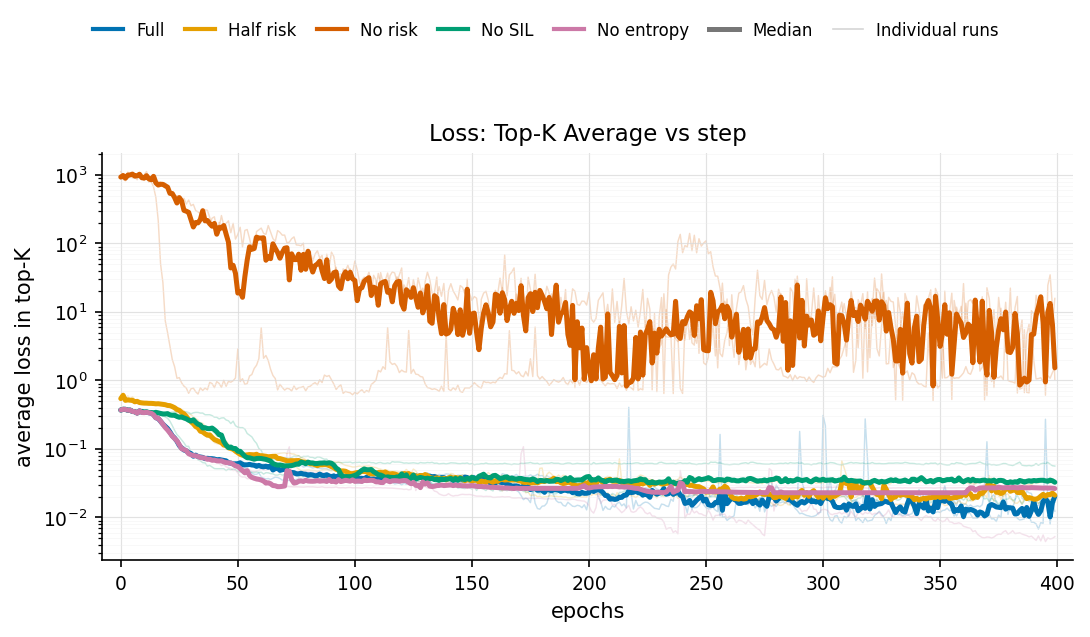

Saved figure to figures/Loss_Top-K_Average_without_no_risk.pdf


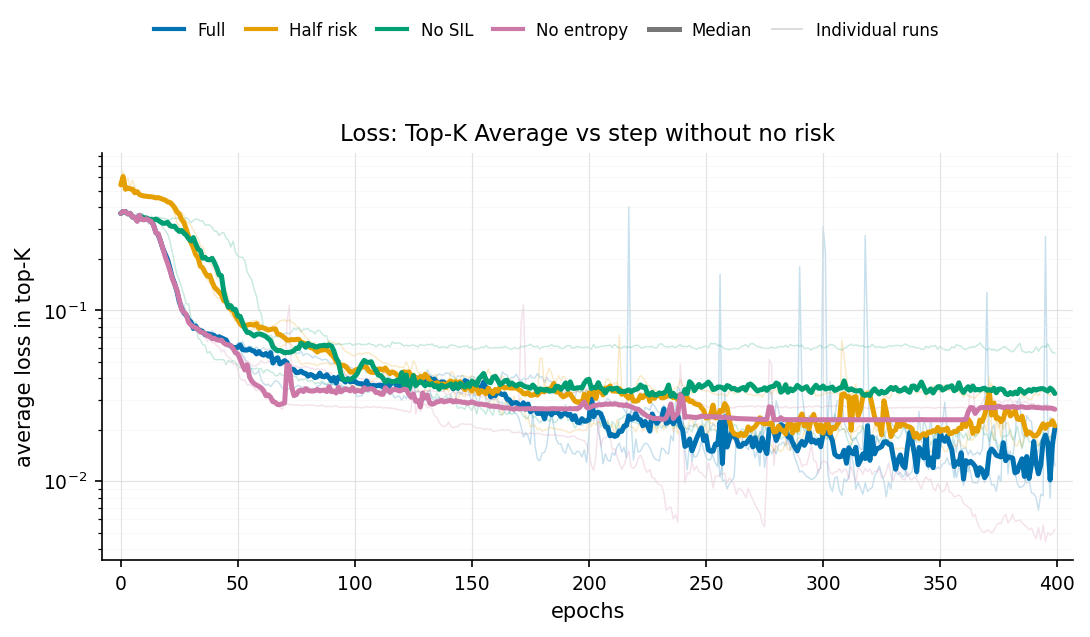

In [5]:
if metrics_df.empty:
    raise ValueError("No metric data was downloaded. Check METRIC_NAMES, project names, and experiment filters.")

plot_df = metrics_df.copy()
plot_df = plot_df[pd.to_numeric(plot_df["value"], errors="coerce").notna()]
plot_df["x"] = pd.to_numeric(plot_df["step"], errors="coerce") * X_AXIS_SCALE
plot_df["value"] = pd.to_numeric(plot_df["value"], errors="coerce")
plot_df = plot_df.dropna(subset=["x", "value"])

if USE_LOG_Y:
    plot_df = plot_df[plot_df["value"] > 0]

if plot_df.empty:
    raise ValueError("No positive metric values are available to plot on a log axis.")

plt.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


def plot_metric(metric_name: str, exclude_projects: set[str] | None = None, title_suffix: str = "") -> None:
    exclude_projects = exclude_projects or set()
    metric_plot_df = plot_df[plot_df["metric"] == metric_name]
    if exclude_projects:
        metric_plot_df = metric_plot_df[~metric_plot_df["project"].isin(exclude_projects)]
    if metric_plot_df.empty:
        print(f"Skipping {metric_name}: no data available.")
        return

    fig, ax = plt.subplots(figsize=(7.35, 4.0), dpi=150)
    fallback_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    project_handles = []

    for project_idx, project_name in enumerate(PROJECT_NAMES):
        project_df = metric_plot_df[metric_plot_df["project"] == project_name]
        if project_df.empty:
            continue

        color = PROJECT_COLORS.get(project_name, fallback_colors[project_idx % len(fallback_colors)])
        project_label = PROJECT_LABELS.get(project_name, project_name)
        project_handles.append(Line2D([0], [0], color=color, lw=2.0, label=project_label))

        for _, run_df in project_df.groupby("experiment_key", sort=False):
            run_df = run_df.sort_values("x")
            ax.plot(
                run_df["x"],
                run_df["value"],
                color=color,
                linewidth=0.7,
                alpha=0.22,
                zorder=1,
            )

        median_df = (
            project_df.groupby("x", as_index=False)["value"]
            .median()
            .sort_values("x")
        )
        ax.plot(
            median_df["x"],
            median_df["value"],
            color=color,
            linewidth=2.4,
            solid_capstyle="round",
            zorder=3,
        )

    if USE_LOG_Y:
        ax.set_yscale("log")

    title = METRIC_TITLES.get(metric_name, f"{metric_name} vs step")
    ax.set_title(f"{title}{title_suffix}", pad=6)
    ax.set_xlabel(X_AXIS_LABEL)
    ax.set_ylabel(METRIC_Y_LABELS.get(metric_name, Y_AXIS_LABEL))
    ax.grid(True, which="major", color="#d9d9d9", linewidth=0.55, alpha=0.75)
    ax.grid(True, which="minor", axis="y", color="#eeeeee", linewidth=0.35, alpha=0.55)
    ax.margins(x=0.02)

    style_handles = [
        Line2D([0], [0], color="#777777", lw=2.4, label="Median"),
        Line2D([0], [0], color="#bbbbbb", lw=0.8, alpha=0.6, label="Individual runs"),
    ]

    legend_handles = project_handles + style_handles
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.06),
        ncol=max(1, len(legend_handles)),
        frameon=False,
        handlelength=1.8,
        columnspacing=1.2,
    )

    if PANEL_LABEL:
        ax.text(
            -0.12,
            1.05,
            PANEL_LABEL,
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            va="bottom",
            ha="left",
        )

    fig.tight_layout(rect=(0, 0, 1, 0.9))
    figure_path = figures_output_root / f"{safe_name(metric_name + title_suffix)}.pdf"
    fig.savefig(figure_path, format="pdf", bbox_inches="tight")
    print(f"Saved figure to {figure_path}")
    plt.show()


for metric_name in METRIC_NAMES:
    plot_metric(metric_name)

plot_metric(
    "Loss: Top-K Average",
    exclude_projects={"logic-circuit-ablation-no-risk"},
    title_suffix=" without no risk",
)